In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

%matplotlib inline

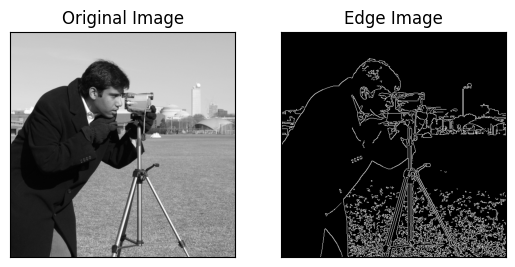

In [26]:
img = data.camera()                                  
edges = cv2.Canny(img, 100, 200)

plt.subplot(121), plt.imshow(img, cmap='gray')
plt.title('Original Image'), plt.xticks([]), plt.yticks([])
plt.subplot(122), plt.imshow(edges, cmap='gray')
plt.title('Edge Image'), plt.xticks([]), plt.yticks([])
plt.show()

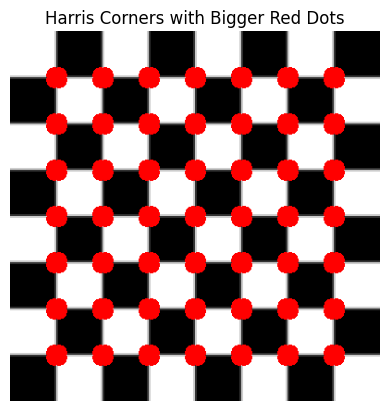

In [28]:
board = data.checkerboard()                        
image = cv2.cvtColor(board, cv2.COLOR_GRAY2BGR)
image = cv2.resize(image, (400, 400), interpolation=cv2.INTER_NEAREST)

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

harris = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)
harris = cv2.dilate(harris, None)

threshold = 0.01 * harris.max()
corner_coords = np.argwhere(harris > threshold)

for y, x in corner_coords:
    cv2.circle(image, (x, y), radius=7, color=(0, 0, 255), thickness=-1)


plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Harris Corners with Bigger Red Dots')
plt.axis('off')
plt.show()

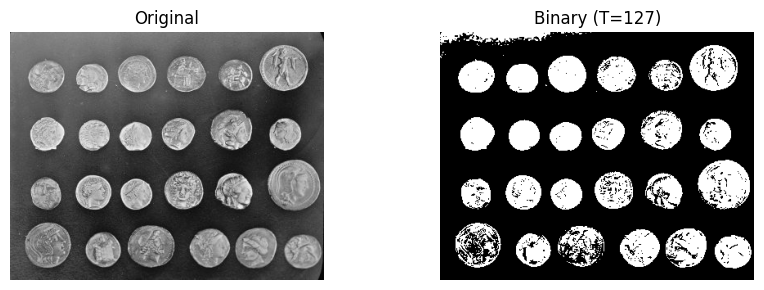

(None, None)

In [29]:
img = data.coins()

T = 127
_, binary = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1), plt.imshow(img, cmap='gray'), plt.title('Original'), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(binary, cmap='gray'), plt.title(f'Binary (T={T})'), plt.axis('off')
plt.tight_layout(), plt.show()

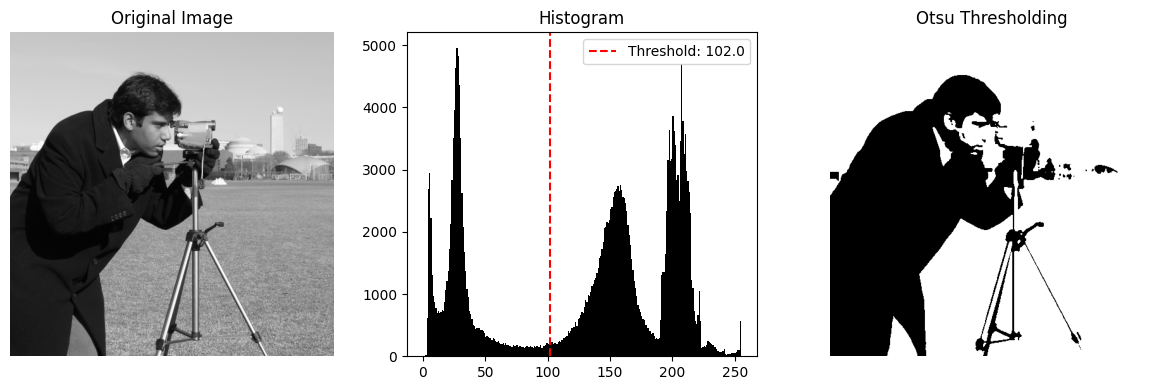

In [37]:
#Otsu's Thresholding

img = data.camera() 


blur = cv2.GaussianBlur(img, (5, 5), 0)


ret, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.hist(img.ravel(), 255, range=[0, 255], color='black')
plt.axvline(x=ret, color='r', linestyle='--', label=f'Threshold: {ret}')
plt.title('Histogram')
plt.legend()

plt.subplot(1, 3, 3)
plt.imshow(thresh, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.tight_layout()
plt.show()